In [1]:
from pathlib import Path 
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import random
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers, Model
import os
from tensorflow.keras.utils import to_categorical

In [2]:
# ===============================
# 0. Reproducibilidad global
# ===============================

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# TensorFlow
tf.random.set_seed(SEED)

# Opcional: determinismo en GPU (más lento pero reproducible)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("Semilla global fijada en:", SEED)

Semilla global fijada en: 42


In [3]:
# ===============================
# 1. Cargar datos procesados
# ===============================

from pathlib import Path
import numpy as np

PROJECT_ROOT = Path().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

# Cargar splits
X_train = np.load(PROCESSED_PATH / "train" / "X.npy")
y_train = np.load(PROCESSED_PATH / "train" / "y.npy")

X_val = np.load(PROCESSED_PATH / "val" / "X.npy")
y_val = np.load(PROCESSED_PATH / "val" / "y.npy")

# IMPORTANTE:
# Las imágenes YA fueron normalizadas en el notebook anterior.
# Aquí SOLO aseguramos tipo float32.
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Pixel range:", X_train.min(), X_train.max())

Train shape: (41741, 128, 128, 3)
Validation shape: (8944, 128, 128, 3)
Pixel range: 0.0 1.0


In [4]:
# ===============================
# 2. Parámetros principales
# ===============================

input_shape = (128, 128, 3)
latent_dim = 128   # pequeño para empezar simple

### Encoder

In [5]:
# ===============================
# 3. Encoder
# ===============================

encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)  # 64x64
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)              # 32x32
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)             # 16x16

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Media y log varianza
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [6]:
# ===============================
# 4. Sampling
# ===============================

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [7]:
# ===============================
# 5. Decoder
# ===============================

decoder_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(16*16*128, activation="relu")(decoder_inputs)
x = layers.Reshape((16,16,128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)  # 32x32
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)   # 64x64
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)   # 128x128

decoder_outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

decoder = Model(decoder_inputs, decoder_outputs, name="decoder")

In [8]:
# ===============================
# 6-7. Modelo VAE personalizado (Keras 3 correcto)
# ===============================
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):
        x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=(1,2,3))
            )

            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data

        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=(1,2,3))
        )

        kl_loss = tf.reduce_mean(
            -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = recon_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [9]:
# ===============================
# 7. Instanciar VAE
# ===============================

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

vae = VAE(encoder, decoder, beta=0.0005)  # beta pequeño evita colapso

vae.compile(optimizer=tf.keras.optimizers.Adam())

In [10]:
# ===============================
# 7.1 Forzar construcción del modelo
# ===============================

vae.build(input_shape=(None, 128, 128, 3))
vae.compile(optimizer=tf.keras.optimizers.Adam())

In [ ]:
history = vae.fit(
    X_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_val,)
)

Epoch 1/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 483s 359ms/step - kl_loss: 761.8819 - loss: 1137.7626 - recon_loss: 1137.3809 - val_kl_loss: 698.3366 - val_loss: 685.7999 - val_recon_loss: 685.4510
Epoch 2/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 362s 277ms/step - kl_loss: 700.6534 - loss: 658.6514 - recon_loss: 658.2997 - val_kl_loss: 669.0147 - val_loss: 649.5779 - val_recon_loss: 649.2436
Epoch 3/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 345s 265ms/step - kl_loss: 703.4783 - loss: 628.8567 - recon_loss: 628.5051 - val_kl_loss: 684.4710 - val_loss: 640.0085 - val_recon_loss: 639.6663
Epoch 4/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 375s 287ms/step - kl_loss: 715.0637 - loss: 612.1004 - recon_loss: 611.7419 - val_kl_loss: 698.0543 - val_loss: 622.7872 - val_recon_loss: 622.4382
Epoch 5/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 364s 279ms/step - kl_loss: 721.2172 - loss: 599.4540 - recon_loss: 599.0933 - val_kl_loss: 714.5806 - val_loss: 620.0483 - val_recon_loss: 619.6912
Epoch 6/35
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 440s 3

In [ ]:
# ==========================================
# A. SUMMARY DEL MODELO
# ==========================================
# Requiere que existan: encoder, decoder, vae
# Nota: vae es subclase, por eso build() es importante antes.

print("===== ENCODER SUMMARY =====")
encoder.summary()

print("\n===== DECODER SUMMARY =====")
decoder.summary()

print("\n===== VAE (SUBCLASS) INFO =====")
# summary() puede no estar disponible/útil en subclass a menos que sea funcional.
# Mostramos variables y shapes como alternativa robusta.
print("Trainable variables:", len(vae.trainable_variables))
for v in vae.trainable_variables[:5]:
    print(" -", v.name, v.shape)
if len(vae.trainable_variables) > 5:
    print(" ...")

In [ ]:
# ==========================================
# B. GRAFICAR ARQUITECTURA (PNG)
# ==========================================
from pathlib import Path
from tensorflow.keras.utils import plot_model

PROJECT_ROOT = Path().resolve().parent
FIGS_PATH = PROJECT_ROOT / "reports" / "figures"
FIGS_PATH.mkdir(parents=True, exist_ok=True)

# Encoder y Decoder (funcionales)
plot_model(
    encoder,
    to_file=str(FIGS_PATH / "encoder_arch.png"),
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

plot_model(
    decoder,
    to_file=str(FIGS_PATH / "decoder_arch.png"),
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

print("Diagramas guardados en:", FIGS_PATH)
print(" - encoder_arch.png")
print(" - decoder_arch.png")

In [ ]:
# ==========================================
# C. SUBIR IMAGEN LOCAL Y RECONSTRUIRLA
# ==========================================
# Uso: ejecuta y selecciona una imagen desde tu máquina.
# Requiere: vae, input_shape (ej. (128,128,3))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

H, W, C = input_shape

uploader = widgets.FileUpload(accept="image/*", multiple=False)
display(uploader)

def _pil_from_upload(upload_widget):
    if len(upload_widget.value) == 0:
        raise ValueError("No se subió ninguna imagen.")
    key = next(iter(upload_widget.value))
    content = upload_widget.value[key]["content"]
    return Image.open(io.BytesIO(content)).convert("RGB")

def preprocess_pil(img_pil, target_hw=(H, W)):
    img_pil = img_pil.resize(target_hw, Image.LANCZOS)
    x = np.array(img_pil).astype("float32") / 255.0
    return x

def apply_gaussian_blur_np(x, sigma=1.2):
    # Blur en TensorFlow para simular input borroso
    x_tf = tf.convert_to_tensor(x[None, ...], dtype=tf.float32)  # (1,H,W,C)
    # Kernel gaussiano separable (aprox) usando conv2d
    # Construimos un kernel 1D y lo aplicamos en X e Y
    radius = int(3 * sigma)
    size = 2 * radius + 1
    coords = tf.range(-radius, radius + 1, dtype=tf.float32)
    kernel_1d = tf.exp(-(coords**2) / (2 * sigma**2))
    kernel_1d = kernel_1d / tf.reduce_sum(kernel_1d)

    # Convertir a kernels 2D separables
    kernel_x = kernel_1d[None, :, None, None]
    kernel_y = kernel_1d[:, None, None, None]

    # Expandir para C canales (depthwise)
    kernel_x = tf.tile(kernel_x, [1, 1, C, 1])
    kernel_y = tf.tile(kernel_y, [1, 1, C, 1])

    # Depthwise conv
    x_tf = tf.nn.depthwise_conv2d(x_tf, kernel_x, strides=[1,1,1,1], padding="SAME")
    x_tf = tf.nn.depthwise_conv2d(x_tf, kernel_y, strides=[1,1,1,1], padding="SAME")

    return x_tf.numpy()[0]

import io

def reconstruct_uploaded(blur_input=True, sigma=1.2):
    img = _pil_from_upload(uploader)
    x = preprocess_pil(img, (W, H))  # PIL resize usa (W,H)
    x_in = apply_gaussian_blur_np(x, sigma=sigma) if blur_input else x

    # Reconstrucción
    recon = vae.predict(x_in[None, ...], verbose=0)[0]

    # Mostrar
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(x)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(x_in)
    plt.title("Input (blurred)" if blur_input else "Input (original)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(np.clip(recon, 0, 1))
    plt.title("Reconstruida (modelo)")
    plt.axis("off")

    plt.show()

# Ejecutar esto después de subir una imagen:
reconstruct_uploaded(blur_input=True, sigma=1.2)

In [ ]:
# ==========================================
# D. GENERAR IMÁGENES DESDE TEXTO O NÚMERO
# ==========================================
# Requiere: decoder, latent_dim

import numpy as np
import hashlib
import matplotlib.pyplot as plt

def _seed_from_text(text: str) -> int:
    # Hash estable -> int 32 bits
    h = hashlib.sha256(text.encode("utf-8")).hexdigest()
    return int(h[:8], 16)

def generate_from_text(prompt: str, n=5, scale=1.0):
    """
    prompt: texto para fijar la semilla
    scale: escala del ruido (mayor = más variación)
    """
    rng = np.random.default_rng(_seed_from_text(prompt))
    z = rng.normal(size=(n, latent_dim)).astype("float32") * float(scale)
    imgs = decoder.predict(z, verbose=0)

    plt.figure(figsize=(2*n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(np.clip(imgs[i], 0, 1))
        plt.axis("off")
    plt.suptitle(f"Generación desde texto | scale={scale}")
    plt.show()

def generate_from_number(value: float, n=5):
    """
    value controla la escala del ruido y un desplazamiento simple.
    Ej: value=0.3 genera más suave; value=2.0 genera más diverso.
    """
    scale = max(0.05, float(value))
    rng = np.random.default_rng(123)
    z = rng.normal(size=(n, latent_dim)).astype("float32") * scale
    imgs = decoder.predict(z, verbose=0)

    plt.figure(figsize=(2*n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(np.clip(imgs[i], 0, 1))
        plt.axis("off")
    plt.suptitle(f"Generación desde número={value}")
    plt.show()

# Ejemplos:
# generate_from_text("una cara con luz suave", n=5, scale=1.0)
# generate_from_number(0.5, n=5)

In [ ]:
# ==========================================
# E. GUARDAR MODELOS EN models/ COMO H5
# ==========================================
from pathlib import Path
import tensorflow as tf

PROJECT_ROOT = Path().resolve().parent
MODELS_PATH = PROJECT_ROOT / "models"
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Nombre distintivo por notebook (cámbialo en cada uno)
MODEL_TAG = "notebook1"   # en notebook2: "notebook2", en notebook3: "notebook3"

# 1) Guardar decoder (funcional)
decoder_path = MODELS_PATH / f"{MODEL_TAG}_decoder.h5"
decoder.save(decoder_path)
print("Decoder guardado en:", decoder_path)

# 2) Wrapper funcional para reconstrucción (Input -> vae(Input))
# Esto evita problemas de serialización de subclass a H5.
inputs = tf.keras.Input(shape=input_shape, name="image_input")
outputs = vae(inputs)  # llama a tu subclass, devuelve reconstrucción
vae_infer = tf.keras.Model(inputs, outputs, name=f"{MODEL_TAG}_vae_reconstruct")

vae_infer_path = MODELS_PATH / f"{MODEL_TAG}_reconstruct.h5"
vae_infer.save(vae_infer_path)
print("Wrapper de reconstrucción guardado en:", vae_infer_path)

print("Modelos disponibles en:", MODELS_PATH)

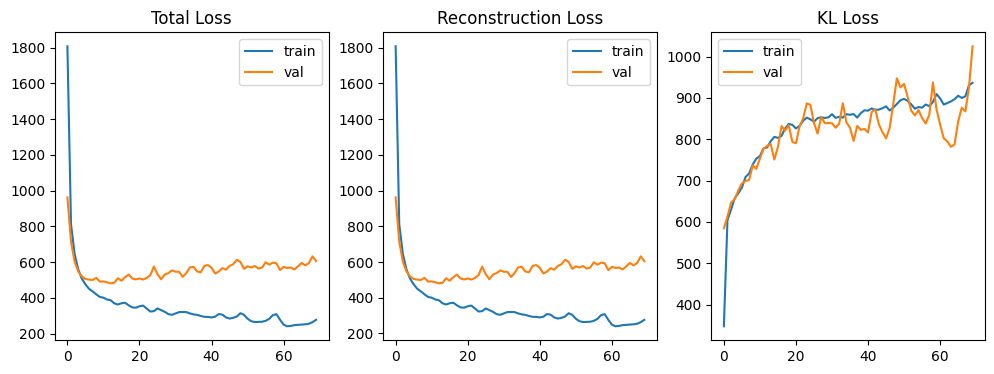

In [ ]:
# ===============================
# 8.2 Curvas de entrenamiento
# ===============================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Total Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction Loss")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL Loss")
plt.legend()

plt.show()

In [ ]:
# ===============================
# 8.3 Evaluación objetiva externa
# ===============================

from sklearn.metrics import mean_squared_error

recon_val = vae.predict(X_val)

mse_val = mean_squared_error(
    X_val.reshape(len(X_val), -1),
    recon_val.reshape(len(recon_val), -1)
)

print("Validation MSE:", mse_val)

44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step
Validation MSE: 0.01239968091249466


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


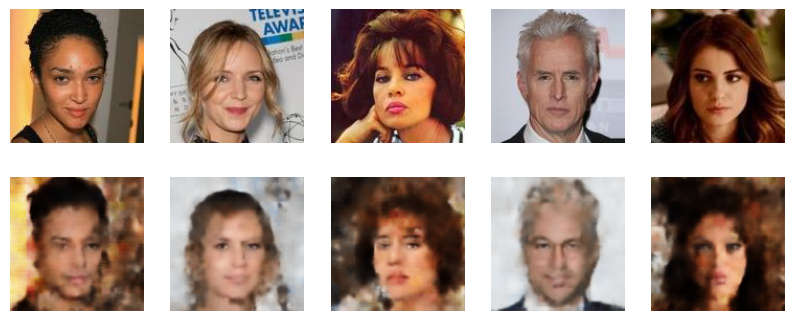

In [ ]:
# ===============================
# 9. Visualizar reconstrucciones
# ===============================

recon = vae.predict(X_val[:5])

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_val[i])
    plt.axis("off")
    
    # Reconstruida
    plt.subplot(2,5,i+6)
    plt.imshow(recon[i])
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


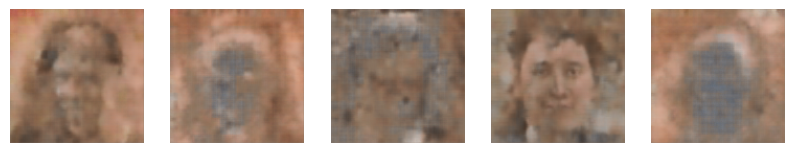

In [ ]:
# ===============================
# 10. Generar caras nuevas (reproducible)
# ===============================

np.random.seed(101)
random_latent = np.random.normal(size=(5, latent_dim))

generated_images = decoder.predict(random_latent)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.show()